# <b><font color='teal'>Homework 24</font></b>

In [11]:
# Импорт библиотек
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

Задача 1. Создайте многопанельный график, используя набор данных Iris. График должен включать:
- Диаграмму рассеяния длины чашелистика по сравнению с шириной чашелистика на первой панели.
- График разброса длины лепестка по ширине лепестка на второй панели.<br>

In [3]:
# Загрузите данные из seaborn (датасет iris) в переменную df_iris
df_iris = sns.load_dataset('iris')
df_iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


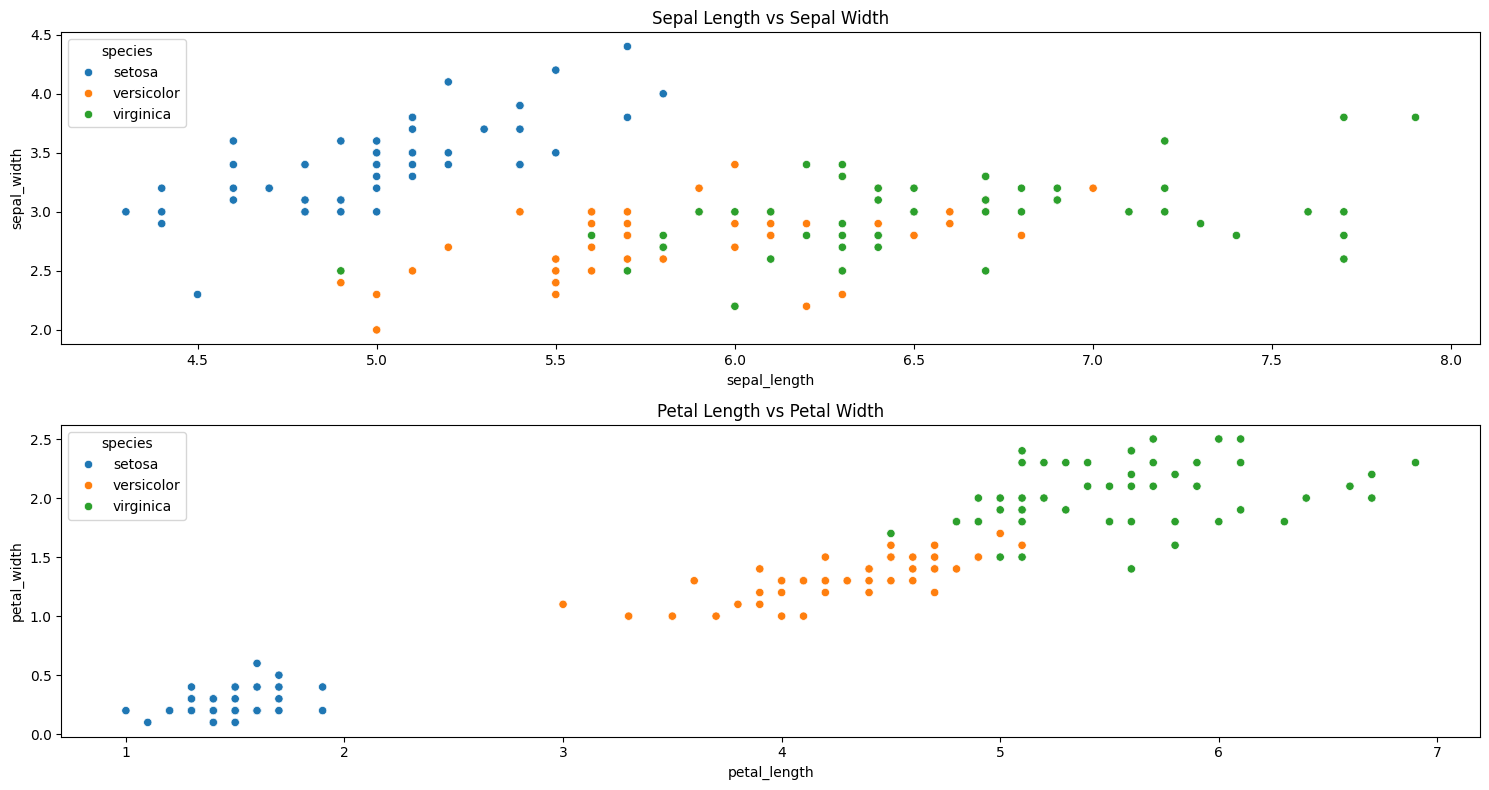

In [12]:
# Используя один из инструментов создания многопанельных графиков (subplot, gridspec, subplot_mosaic)
# создайте "холст" с двумя панелями и нарисуйте на них графики
# на первом графике - scatterplot: по x - длина чашелистика, по y - ширина чашелистика, hue - species
# на втором графике - scatterplot: по x - длина лепестка, по y - ширина лепестка, hue - species
fig = plt.figure(figsize = (15, 8))
gs = GridSpec(2, 2, figure = fig)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, :])
sns.scatterplot(data = df_iris, x = 'sepal_length', y = 'sepal_width', hue = 'species', ax = ax1)
sns.scatterplot(data = df_iris, x = 'petal_length', y = 'petal_width', hue = 'species', ax = ax2)
ax1.set_title('Sepal Length vs Sepal Width')
ax2.set_title('Petal Length vs Petal Width')
plt.tight_layout()
plt.show()

Задача 2. Создайте тепловую карту корреляционной матрицы набора данных Tips. Аннотируйте тепловую карту значениями корреляции и используйте пользовательскую палитру расходящихся цветов.

In [13]:
# Загрузите данные из seaborn (датасет tips) в переменную df_tips
df_tips = sns.load_dataset('tips')
df_tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [14]:
# Создайте корреляционную матрицу, используя только числовые столбцы
df_tips_num = df_tips.select_dtypes(include=[np.number])
correlation_matrix = df_tips_num.corr()
print(correlation_matrix)

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


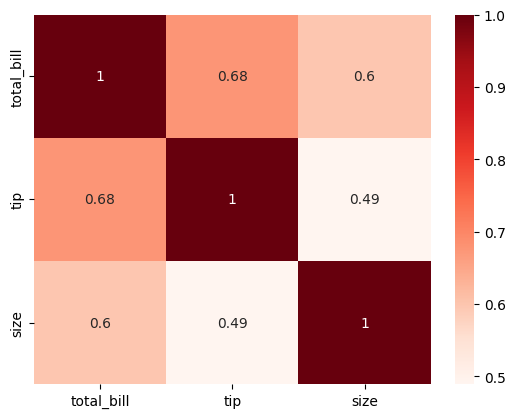

In [16]:
# Постройте heatmap с параметрами cmap, annot
sns.heatmap(correlation_matrix, cmap = 'Reds', annot = True)
plt.show()

Задача 3. Проверьте, значительно ли отличается средняя длина лепестка у видов Iris setosa от 1,5 см.

In [ ]:
# Сформулируйте гипотезы H_0 и H_1
# H_0: Средняя длина лепестка у видов Iris setosa равна 1,5 см.
# H_1: Средняя длина лепестка у видов Iris setosa не равна 1,5 см.



In [19]:
# Выберите необходимую статистику и вычислите значение статистики и p-value
t_stat, p_value = stats.ttest_1samp(df_iris[df_iris['species'] == 'setosa']['petal_length'], popmean=1.5)
print(f'T-statistic: {t_stat}, P-value: {p_value}')


T-statistic: -1.547244001617496, P-value: 0.12823939581745414


In [18]:
# Выведите результаты с интерпретацией
if p_value < 0.05:
    print("Существует статистически значимая разница между средней длиной лепестка у видов Iris setosa и 1,5 см.")
else:
    print("Нет статистически значимой разницы между средней длиной лепестка у видов Iris setosa и 1,5 см.")

Нет статистически значимой разницы между средней длиной лепестка у видов Iris setosa и 1,5 см.
